# 9. Causal questions, and the one COMPAS cannot answer

The other eight notebooks measure associations and are careful to call them that.
This one asks the question they keep running into and cannot answer: **which part
of a measured disparity is the world, and which part is the label.**

That is a causal question, so the first half is the machinery, done on a toy.
The second half puts it on COMPAS.

Two papers already in `papers/` are used here for the first time:

- Kusner, Loftus, Russell & Silva (2017), `papers/kusner-2017-counterfactual-fairness.pdf`
- Kilbertus et al. (2017), `papers/kilbertus-2017-causal-reasoning.pdf`

And two that are not bundled:

- Westreich & Greenland (2013), *The Table 2 Fallacy*, Am J Epidemiol 177(4):292-298
- Cinelli & Hazlett (2020), *Making Sense of Sensitivity*, JRSS-B 82(1):39-67

**The rule this notebook keeps.** Every claim that the data cannot decide is
followed by a cell showing that it cannot. Philosophy here is what is left after
the measurement stops, not what replaces it.

In [1]:
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# numpy 2.3 on macOS Accelerate emits spurious divide/overflow warnings from
# matmul on well-conditioned matrices. The arithmetic is correct; the warnings
# are not. Nothing below relies on them being off.
np.seterr(all='ignore')
warnings.filterwarnings('ignore')


def ols(y, *cols):
    """Coefficients, standard errors, t, df, R2. Five lines, no library."""
    Z = np.ascontiguousarray(np.c_[np.ones(len(y)), np.column_stack(cols)], dtype=float)
    b = np.linalg.lstsq(Z, y, rcond=None)[0]
    resid = y - Z @ b
    df = len(y) - Z.shape[1]
    se = np.sqrt(np.diag(np.linalg.inv(Z.T @ Z)) * (resid @ resid / df))
    return b, se, b / se, df, 1 - resid.var() / y.var()

## 1. The mechanics, on the toy everybody uses

Ice cream sales and drownings rise together. Temperature drives both. Ice cream
causes no drownings. It is the standard first example, and it is the one an LLM
will hand you if you ask for a causal-inference hello world.

Here is that tutorial's code, run.

In [2]:
np.random.seed(42)
n = 5000
temperature = np.random.normal(30, 5, n)
ice_cream   = 50 + 2 * temperature + np.random.normal(0, 5, n)
drowning    = 10 + 0.5 * temperature + np.random.normal(0, 2, n)
toy = pd.DataFrame({'temperature': temperature,
                    'ice_cream_sales': ice_cream,
                    'drowning_deaths': drowning})

claimed = {('temperature', 'ice_cream_sales'): 0.97,
           ('temperature', 'drowning_deaths'): 0.96,
           ('ice_cream_sales', 'drowning_deaths'): 0.94}

print(f"  {'':<34}{'tutorial said':>15}{'measured':>11}")
for (a, b), c in claimed.items():
    short = {'temperature': 'temp', 'ice_cream_sales': 'ice cream', 'drowning_deaths': 'drowning'}
    print(f"  {'corr(' + short[a] + ', ' + short[b] + ')':<34}{c:>15.2f}{toy[a].corr(toy[b]):>11.2f}")

rf = RandomForestRegressor(random_state=0)
r2_ice = cross_val_score(rf, toy[['ice_cream_sales']], drowning, cv=5).mean()
b_naive, *_ = ols(drowning, ice_cream)
print()
print(f"  {'naive coef, ice cream -> drowning':<34}{'~0.5':>15}{b_naive[1]:>11.3f}")
print(f"  {'RF R2 from ice cream alone':<34}{'0.88+':>15}{r2_ice:>11.3f}")

                                      tutorial said   measured
  corr(temp, ice cream)                        0.97       0.89
  corr(temp, drowning)                         0.96       0.78
  corr(ice cream, drowning)                    0.94       0.69



  naive coef, ice cream -> drowning            ~0.5      0.198
  RF R2 from ice cream alone                  0.88+      0.230


Every number the tutorial printed as "Output you'll see" is wrong. That block was
never run.

The correlations are inflated by 9%, 23% and 36%, the naive coefficient is 2.5x
too large, and the R² is out by a factor of four. The last one is not cosmetic.
The tutorial's whole punchline is *"a RandomForest predicts drowning from ice
cream with high accuracy, but the causal effect is zero."* At **R² = 0.23** there
is no high accuracy to contrast with. The real lesson is quieter and better:
**a weak predictor can be a completely confounded one.**

The causal conclusion, though, is right. Adjust for temperature and the ice cream
coefficient collapses.

In [3]:
b_adj, *_ = ols(drowning, ice_cream, temperature)
print(f"  truth:  ice cream 0.000    temperature 0.500\n")
print(f"  no adjustment            ice cream {b_naive[1]:+.4f}")
print(f"  adjusted for temperature ice cream {b_adj[1]:+.4f}   temperature {b_adj[2]:+.4f}")

# The same question, put to a flexible predictive model with the confounder in it.
rf_both = RandomForestRegressor(random_state=0).fit(toy[['ice_cream_sales', 'temperature']], drowning)
imp = rf_both.feature_importances_
print(f"\n  RandomForest with both, feature importance:"
      f"  ice cream {imp[0]:.3f}   temperature {imp[1]:.3f}")
print(f"  RF R2, ice cream alone {r2_ice:.3f}"
      f"   -> with temperature {cross_val_score(RandomForestRegressor(random_state=0), toy[['ice_cream_sales','temperature']], drowning, cv=5).mean():.3f}")

  truth:  ice cream 0.000    temperature 0.500

  no adjustment            ice cream +0.1981
  adjusted for temperature ice cream -0.0023   temperature +0.5035



  RandomForest with both, feature importance:  ice cream 0.192   temperature 0.808


  RF R2, ice cream alone 0.230   -> with temperature 0.526


## 1a. What the library adds

`dowhy` is the usual recommendation. Run it on the same data and the same graph.

One practical note: the documented API takes the graph as a `dot` string, and
that path is broken against `pydot` 4.0.1 (`Graph.get_strict() takes 1 positional
argument but 2 were given`). Passing a `networkx.DiGraph` works.

In [4]:
import networkx as nx
from dowhy import CausalModel

g = nx.DiGraph([('temperature', 'ice_cream_sales'),
                ('temperature', 'drowning_deaths'),
                ('ice_cream_sales', 'drowning_deaths')])
model = CausalModel(data=toy, treatment='ice_cream_sales',
                    outcome='drowning_deaths', graph=g)
est = model.identify_effect(proceed_when_unidentifiable=True)
dw = model.estimate_effect(est, method_name='backdoor.linear_regression')

print(f"  dowhy picked the backdoor set: {est.get_backdoor_variables()}")
print(f"  dowhy estimate           {dw.value:+.4f}")
print(f"  the five-line ols above  {b_adj[1]:+.4f}")

ref = model.refute_estimate(est, dw, method_name='placebo_treatment_refuter',
                            placebo_type='permute', num_simulations=30)
print(f"\n  placebo refuter: effect on a shuffled treatment {ref.new_effect:+.4f}")

  dowhy picked the backdoor set: ['temperature']
  dowhy estimate           -0.0023
  the five-line ols above  -0.0023

  placebo refuter: effect on a shuffled treatment +0.0003


Identical to four decimal places, because it *is* the same regression. The
library's contribution is not the estimate. It is `identify_effect`, which read
the graph and returned the adjustment set `['temperature']` - the one step a
regression cannot do for you.

One warning about the last line. The placebo refuter can only falsify. Passing it
is weak evidence, not confirmation; a confounded estimate passes it comfortably,
because shuffling the treatment destroys the confounding along with everything
else.

**So: is causal inference different from predictive modelling with an extra
variable in it?** Here, arithmetically, no. Same coefficients, same answer, and
the RandomForest's feature importance points the same way. That is the honest
answer, and it is the one the tutorial dodged.

The difference is the next cell.

## 1b. The Table 2 fallacy

One regression returns *k* coefficients. **At most one of them is a causal
effect, and nothing in the fit tells you which.**

Westreich & Greenland named this after the table in an epidemiology paper where
the exposure coefficient and all the "adjustment" coefficients are printed in one
column, as if they were the same kind of quantity.

Extend the toy so that temperature reaches drowning through a mediator - people
in the water. Ice cream still causes nothing.

In [5]:
rng = np.random.default_rng(0)
n = 20000
T = rng.normal(30, 5, n)                    # temperature
I = 50 + 2.0 * T + rng.normal(0, 5, n)      # ice cream sales
S = 10 + 1.5 * T + rng.normal(0, 4, n)      # people in the water
D = 2 + 0.4 * S + rng.normal(0, 2, n)       # drownings

# truth:  ice cream -> drowning = 0.00
#         swimmers  -> drowning = 0.40
#         temperature -> drowning, total = 1.5 * 0.4 = 0.60
b1, _, _, _, r2a = ols(D, I, T)
b2, _, _, _, r2b = ols(D, I, T, S)

print(f"  {'':<30}{'ice cream':>11}{'temperature':>13}{'swimmers':>11}{'R2':>9}")
print(f"  {'TRUE causal effect':<30}{0.00:>11.3f}{0.60:>13.3f}{0.40:>11.3f}{'':>9}")
print("  " + "-" * 72)
print(f"  {'D ~ ice + temp':<30}{b1[1]:>11.3f}{b1[2]:>13.3f}{'':>11}{r2a:>9.4f}")
print(f"  {'D ~ ice + temp + swimmers':<30}{b2[1]:>11.3f}{b2[2]:>13.3f}{b2[3]:>11.3f}{r2b:>9.4f}")

                                  ice cream  temperature   swimmers       R2
  TRUE causal effect                  0.000        0.600      0.400         
  ------------------------------------------------------------------------
  D ~ ice + temp                      0.008        0.585              0.5781
  D ~ ice + temp + swimmers           0.006       -0.010      0.400   0.7424


Read the second row against the first.

Adding swimmers **improves the fit** - R² goes 0.578 to 0.742 - and in the
better-fitting model the temperature coefficient falls from +0.585 to **−0.010**.
The true total effect of temperature on drowning is **+0.60**. The model that
predicts better gives an answer that is wrong by the entire effect.

The ice cream coefficient is correct in both rows. So one regression, two
coefficients, and exactly one of them survives the extra variable. Nothing in R²,
nothing in the standard errors, and nothing in a feature-importance ranking
distinguishes them. Only the graph does: swimmers is a **mediator** of
temperature, so conditioning on it removes the path you were trying to measure,
while for ice cream the same variable is a harmless covariate.

**That is the whole answer to "why not just add more variables".** Adding
variables is not free and not neutral. It is a choice about which effect you are
still allowed to read, and the fit statistics cannot make it for you.

## 2. "Do I need accurate data on the confounder?"

The usual answer is yes, and random numbers adjust for nothing. Both true, and
both leave out the interesting part, which is what happens **in between**.

Adjust for a noisy version of temperature and sweep the noise.

In [6]:
rng = np.random.default_rng(1)
n = 20000
T = rng.normal(30, 5, n)
I = 50 + 2.0 * T + rng.normal(0, 5, n)
D = 10 + 0.5 * T + rng.normal(0, 2, n)      # ice cream has no effect on drowning

b_none, *_ = ols(D, I)
b_real, *_ = ols(D, I, T)
print(f"  no adjustment at all        {b_none[1]:+.4f}")
print(f"  adjusted for real temp      {b_real[1]:+.4f}   (truth 0.0000)\n")

sweep = []
print(f"  {'proxy noise sd':>15}{'reliability':>13}{'estimate':>11}{'bias remaining':>17}")
for sd in [0, 1, 2, 3, 5, 8, 12, 20, 40]:
    proxy = T + rng.normal(0, sd, n)
    b, *_ = ols(D, I, proxy)
    reliability = T.var() / (T.var() + sd ** 2)
    remaining = b[1] / b_none[1]
    sweep.append((reliability, b[1]))
    print(f"  {sd:>15}{reliability:>13.3f}{b[1]:>11.4f}{remaining:>16.0%}")

  no adjustment at all        +0.2001
  adjusted for real temp      +0.0013   (truth 0.0000)

   proxy noise sd  reliability   estimate   bias remaining
                0        1.000     0.0013              1%
                1        0.961     0.0349             17%
                2        0.861     0.0898             45%
                3        0.733     0.1287             64%
                5        0.497     0.1678             84%
                8        0.279     0.1844             92%
               12        0.146     0.1938             97%
               20        0.058     0.1974             99%
               40        0.015     0.1997            100%


A proxy with **reliability 0.86** - a correlation of 0.93 with the true
confounder, which most people would call a good proxy - leaves **45% of the bias
in place**. At reliability 0.50 it leaves 84%.

This is classical measurement-error attenuation, and it is why "we controlled for
socioeconomic status using postcode" is a weaker sentence than it sounds. The
adjustment is not partial in proportion to the proxy's quality. It is much worse
than that: reliability falls off linearly and the surviving bias does not.

The chart at the end of the notebook plots the whole curve.

## 2a. When you have no data on the confounder at all

You cannot fix it. You can put a number on how strong it would have to be.

Cinelli & Hazlett's **robustness value** is that number: the share of residual
variance an unobserved confounder must explain in *both* the treatment and the
outcome to drive the estimate to zero.

The reason to run it here rather than on real data is that we know the answer.
The confounder is temperature, and we can measure exactly how strong it is - so
the sensitivity analysis can be scored rather than believed.

In [7]:
b, se, t, dfree, _ = ols(D, I)
f = abs(t[1]) / np.sqrt(dfree)
RV = 0.5 * (np.sqrt(f ** 4 + 4 * f ** 2) - f ** 2)
print(f"  unadjusted estimate {b[1]:+.4f}  (t = {abs(t[1]):.1f}, df = {dfree})")
print(f"  robustness value    {RV:.3f}")
print(f"  -> a confounder explaining {RV:.0%} of residual variance in both ice cream")
print(f"     and drowning would account for the whole estimate\n")


def partial_r2(y, focus, *others):
    if others:
        Zo = np.ascontiguousarray(np.c_[np.ones(len(y)), np.column_stack(others)], dtype=float)
        y = y - Zo @ np.linalg.lstsq(Zo, y, rcond=None)[0]
        focus = focus - Zo @ np.linalg.lstsq(Zo, focus, rcond=None)[0]
    return np.corrcoef(y, focus)[0, 1] ** 2


r2_treat = partial_r2(I, T)          # confounder with treatment
r2_out   = partial_r2(D, T, I)       # confounder with outcome, given treatment
print(f"  temperature explains {r2_treat:.1%} of ice cream")
print(f"  temperature explains {r2_out:.1%} of drowning, given ice cream\n")

# Cinelli & Hazlett bound: how much bias a confounder of that strength can create
bound = se[1] * np.sqrt(dfree) * np.sqrt(r2_out * r2_treat / (1 - r2_treat))
print(f"  bias the bound allows for a confounder that strong   {bound:+.4f}")
print(f"  bias temperature actually caused                     {b[1] - b_real[1]:+.4f}")

  unadjusted estimate +0.2001  (t = 138.0, df = 19998)
  robustness value    0.610
  -> a confounder explaining 61% of residual variance in both ice cream
     and drowning would account for the whole estimate

  temperature explains 80.1% of ice cream
  temperature explains 23.4% of drowning, given ice cream

  bias the bound allows for a confounder that strong   +0.1988
  bias temperature actually caused                     +0.1988


The bound predicts **0.199** and the actual bias is **0.199**. The formula is
tight here because the world is linear and temperature is the only confounder,
which is exactly the case the derivation assumes.

Note what the headline number does *not* say. The robustness value is **0.61**,
and temperature explains 80% of the treatment but only **23%** of the outcome -
below 0.61 on one of the two. Read the robustness value as a threshold on both
quantities at once and you would have concluded that temperature is not strong
enough to explain the estimate. It is, comfortably. The robustness value is the
point where *equal* strengths suffice; asymmetric confounders reach the same
place by a different route, and for those you need the bound, not the headline.

That is the sensitivity analysis validated against a known answer, which is the
only way to find out that the convenient summary of it is misleading.

## 3. COMPAS

Notebook 6 reproduced both sides of the 2016 argument and showed they are both
right. It stopped where the interesting question starts.

Northpointe's defence and ProPublica's attack are both statements about a column
called `two_year_recid`. Neither side asked what is in that column.

In [8]:
compas = pd.read_csv('../data/compas-scores-two-years.csv')
compas = compas.loc[:, ~compas.columns.duplicated()]
compas = compas[(compas.days_b_screening_arrest.abs() <= 30) & (compas.is_recid != -1) &
                (compas.c_charge_degree != 'O') & (compas.score_text != 'N/A')]
compas = compas[compas.race.isin(['African-American', 'Caucasian'])].copy()
compas['high_risk'] = compas.decile_score >= 5
blk = compas.race == 'African-American'
wht = compas.race == 'Caucasian'
print(f"  {len(compas)} defendants: {blk.sum()} Black, {wht.sum()} white\n")

rec = compas[compas.two_year_recid == 1]
felony = rec.r_charge_degree.astype(str).str.startswith('(F')
print(f"  rows the label counts as recidivism   {len(rec)}  ({compas.two_year_recid.mean():.1%})")
print(f"  of those, a felony arrest             {felony.sum():>5}  {felony.mean():>6.1%}")
print(f"  of those, a lesser arrest             {(~felony).sum():>5}  {(~felony).mean():>6.1%}")
print(f"  of those, a violent re-arrest         {rec.is_violent_recid.sum():>5}  {rec.is_violent_recid.mean():>6.1%}\n")
print("  the three commonest charge degrees behind the label:")
for k, v in rec.r_charge_degree.value_counts().head(3).items():
    name = {'(M1)': 'misdemeanour, first degree', '(M2)': 'misdemeanour, second degree',
            '(F3)': 'felony, third degree'}.get(str(k), '')
    print(f"    {str(k):<7}{v:>6}  {v / len(rec):>6.1%}   {name}")

  5278 defendants: 3175 Black, 2103 white

  rows the label counts as recidivism   2483  (47.0%)
  of those, a felony arrest               804   32.4%
  of those, a lesser arrest              1679   67.6%
  of those, a violent re-arrest           578   23.3%

  the three commonest charge degrees behind the label:
    (M1)      869   35.0%   misdemeanour, first degree
    (M2)      781   31.5%   misdemeanour, second degree
    (F3)      639   25.7%   felony, third degree


**Two thirds of "recidivism" in this file is a misdemeanour arrest**, and under a
quarter of it is violent. The label is not reoffending. It is *being arrested
again within two years, for anything.*

That is not a quibble about wording. An arrest is the output of a process with
two inputs - what somebody did, and how heavily their neighbourhood is policed.
The file records the product and no column separates the factors.

So `two_year_recid` measures offending **plus enforcement**, and every quantity
computed from it in notebook 6 inherits both.

## 3a. Two worlds that write the same file

Here is the identifiability problem, made runnable rather than argued.

**World A.** Offending genuinely differs between the two groups. Policing is
even-handed. Arrests measure offending, and the score is picking up a real
difference in risk.

**World B.** Offending is the same. Policing is not: one group is watched more
closely, so more of what they do becomes an arrest, and years of that also leaves
them with more prior arrests on file.

Both are simulated below. Neither is fitted to the error rates - each is tuned to
match four published marginals only: the two base rates and the two mean prior
counts.

In [9]:
from scipy.optimize import least_squares

TARGET = np.array([0.523, 0.391, 4.24, 2.29])     # base B, base W, priors B, priors W
FLAG_SHARE = 0.478                                 # share COMPAS calls high risk


def simulate(kind, th, n=8000, seed=0):
    rng = np.random.default_rng(seed)
    grp = np.r_[np.ones(n), np.zeros(n)].astype(bool)          # True = Black
    # age distributions as they are in the file: means 32.4 and 37.5, sd ~11.7
    age = np.r_[18 + rng.gamma((14.4 / 11.7) ** 2, 11.7 ** 2 / 14.4, n),
                18 + rng.gamma((19.5 / 11.7) ** 2, 11.7 ** 2 / 19.5, n)]
    p0, p1, b0, last = th
    if kind == 'A':                       # offending differs, policing is equal
        C = rng.normal(np.where(grp, last, 0.0), 1.0)
        priors_mult = np.ones(2 * n)
        caught = np.ones(2 * n)
    else:                                 # offending is equal, policing differs
        C = rng.normal(0.0, 1.0, 2 * n)
        priors_mult = np.where(grp, 1.0, last ** 2.1)   # priors accrue over many years
        caught = np.where(grp, 1.0, last)               # detection in the 2-year window
    priors = rng.poisson(np.exp(p0 + p1 * C - 0.022 * (age - 34)) * priors_mult)
    offend = rng.random(2 * n) < 1 / (1 + np.exp(-(b0 + 0.62 * C - 0.030 * (age - 34))))
    label = offend & (rng.random(2 * n) < caught)
    return grp, age, priors, offend, label


def marginals(kind, th, seed=0):
    grp, age, priors, offend, label = simulate(kind, th, seed=seed)
    return np.array([label[grp].mean(), label[~grp].mean(), priors[grp].mean(), priors[~grp].mean()])


fit = {}
for kind, x0, lo, hi in (('A', [1.2, .55, -.1, 1.0], [-2, .05, -3, 0.0], [3, 2, 3, 3.0]),
                         ('B', [1.2, .55, -.1, .75], [-2, .05, -3, 0.3], [3, 2, 3, 1.0])):
    r = least_squares(lambda t: (marginals(kind, t) - TARGET) / np.array([.05, .05, .5, .5]),
                      x0, bounds=(lo, hi), diff_step=0.05)
    fit[kind] = r.x
    tail = 'group shift in offending' if kind == 'A' else 'policing ratio, white/Black'
    print(f"  world {kind}: {tail} = {r.x[3]:.3f}")

  world A: group shift in offending = 0.697


  world B: policing ratio, white/Black = 0.791


In [10]:
def evaluate(kind, th, seeds=range(12)):
    acc = []
    for s in seeds:
        grp, age, priors, offend, label = simulate(kind, th, seed=100 + s)
        X = np.c_[priors, age]
        p = LogisticRegression(max_iter=2000).fit(X, label).predict_proba(X)[:, 1]
        flag = p >= np.quantile(p, 1 - FLAG_SHARE)          # the score never sees race
        y, r_ = label.astype(int), grp.astype(float)
        acc.append(dict(
            base_b=label[grp].mean(), base_w=label[~grp].mean(),
            pri_b=priors[grp].mean(), pri_w=priors[~grp].mean(),
            fpr_b=flag[grp & ~label].mean(), fpr_w=flag[~grp & ~label].mean(),
            fnr_b=1 - flag[grp & label].mean(), fnr_w=1 - flag[~grp & label].mean(),
            auc=roc_auc_score(label, p),
            off_b=offend[grp].mean(), off_w=offend[~grp].mean(),
            race_raw=LogisticRegression(max_iter=4000).fit(r_[:, None], y).coef_[0][0],
            race_ctrl=LogisticRegression(max_iter=4000).fit(np.c_[r_, priors, age], y).coef_[0][0]))
    return {k: float(np.mean([a[k] for a in acc])) for k in acc[0]}


worlds = {k: evaluate(k, fit[k]) for k in ('A', 'B')}
NAME = {'A': 'world A  offending differs', 'B': 'world B  policing differs'}

print(f"  {'':<27}{'base B':>8}{'base W':>8}{'pri B':>7}{'pri W':>7}"
      f"{'FPR B':>8}{'FPR W':>8}{'FPR gap':>9}{'AUC':>7}")
print("  " + "-" * 89)
for k in ('A', 'B'):
    w = worlds[k]
    print(f"  {NAME[k]:<27}{w['base_b']:>8.1%}{w['base_w']:>8.1%}{w['pri_b']:>7.2f}{w['pri_w']:>7.2f}"
          f"{w['fpr_b']:>8.1%}{w['fpr_w']:>8.1%}{w['fpr_b'] - w['fpr_w']:>+9.1%}{w['auc']:>7.3f}")
print(f"  {'COMPAS, the actual file':<27}{0.523:>8.1%}{0.391:>8.1%}{4.24:>7.2f}{2.29:>7.2f}"
      f"{0.423:>8.1%}{0.220:>8.1%}{0.203:>+9.1%}{0.711:>7.3f}")

print("\n  the quantity the two worlds disagree about, which is in no file:")
for k in ('A', 'B'):
    w = worlds[k]
    print(f"    {NAME[k]:<27} true offending   Black {w['off_b']:.1%}   white {w['off_w']:.1%}"
          f"   ratio {w['off_b'] / w['off_w']:.2f}")

                               base B  base W  pri B  pri W   FPR B   FPR W  FPR gap    AUC
  -----------------------------------------------------------------------------------------
  world A  offending differs    52.4%   39.4%   4.25   2.36   51.7%   26.2%   +25.6%  0.658
  world B  policing differs     53.0%   39.2%   4.25   2.33   53.2%   26.9%   +26.3%  0.643
  COMPAS, the actual file       52.3%   39.1%   4.24   2.29   42.3%   22.0%   +20.3%  0.711

  the quantity the two worlds disagree about, which is in no file:
    world A  offending differs  true offending   Black 52.4%   white 39.4%   ratio 1.33
    world B  policing differs   true offending   Black 53.0%   white 49.4%   ratio 1.07


The two worlds agree on everything the file records and disagree completely about
what is happening.

Both hit the four target marginals. Both produce a false positive rate roughly
twice as high for Black defendants - ProPublica's finding - from a score that was
never shown race. And in world A the true offending ratio is **1.33** while in
world B it is **1.07**, the remainder of which is the age difference between the
two groups rather than anything about the groups themselves.

**Neither the score, the label, nor any column in the file distinguishes them.**

Two honest notes on the fit. The simulated false positive gap is around **+26%**
against an observed **+20.3%**, and the simulated AUC is **0.64-0.66** against
COMPAS's **0.711**. Neither was a target, and I have not tuned to them; the
simulation overshoots the gap it was not asked to match. The claim being made is
about the *direction and the indistinguishability*, not about a replication of
COMPAS to three decimal places.

This is the sense in which the COMPAS argument was never going to be settled by
better statistics. It is not a hard estimation problem. It is an **unidentified**
one: two data-generating processes, one observational distribution.

### What would separate them

Not more careful analysis of this file. Different measurements, all of which
exist:

- **Victimisation surveys.** The US National Crime Victimization Survey asks
  people what happened to them, not what the police recorded. It measures
  offending through a channel that does not pass through arrest.
- **Self-reported drug use against drug arrests.** Surveys have found broadly
  similar rates of use across racial groups in the US, alongside arrest rates
  several times higher for Black Americans. That comparison is informative
  precisely because it puts a non-arrest measurement next to an arrest one.
- **Audit studies.** Randomise the *signal* of race and hold everything else
  fixed. Section 4 comes back to why this is the only genuine intervention
  available here.

Every one of these is a measurement outside the dataset. That is the practical
content of "you need domain knowledge": not a wiser reading of the file, but a
second file, collected differently.

## 3b. How much model is there to defend?

The argument for using a sensitive attribute, or a proxy for one, is always that
accuracy would suffer without it. That is a factual claim, and on this dataset it
is checkable.

Dressel & Farid (2018) found COMPAS - a 137-item instrument - matched by a
logistic regression on two features.

In [11]:
X2 = compas[['age', 'priors_count']].to_numpy(float)
y2 = compas.two_year_recid.to_numpy()
p2 = LogisticRegression(max_iter=2000).fit(X2, y2).predict_proba(X2)[:, 1]

print(f"  {'COMPAS decile_score (137 items)':<34}AUC {roc_auc_score(y2, compas.decile_score):.3f}")
print(f"  {'logistic on age + priors':<34}AUC {roc_auc_score(y2, p2):.3f}")
print(f"  {'priors_count alone':<34}AUC {roc_auc_score(y2, compas.priors_count):.3f}")
print(f"  {'age alone':<34}AUC {roc_auc_score(y2, -compas.age):.3f}")

  COMPAS decile_score (137 items)   AUC 0.711
  logistic on age + priors          AUC 0.728
  priors_count alone                AUC 0.678
  age alone                         AUC 0.608


Two features beat the instrument, 0.728 against 0.711. Dressel & Farid's result
replicates on this file.

That matters for the argument in a specific way. Whatever COMPAS is doing, it is
not a sophisticated system whose accuracy would collapse without some carefully
chosen feature. It is mostly **age and prior arrests**. So the question "may we
use this variable, given what it costs in accuracy" is, for this system, being
asked about a model with very little accuracy in it to trade.

And it puts almost the entire weight of the score on `priors_count`.

## 3c. Why "just control for criminal history" is not the neutral move

The standard advice - and the one an LLM will give you - is: do not use race, use
the legitimate risk factors instead. Prior record. Poverty. Neighbourhood.

Run it.

In [12]:
race = blk.astype(float).to_numpy()
priors_real = compas.priors_count.to_numpy(float)
age_real = compas.age.to_numpy(float)

c_raw  = LogisticRegression(max_iter=4000).fit(race[:, None], y2).coef_[0][0]
c_ctrl = LogisticRegression(max_iter=4000).fit(np.c_[race, priors_real, age_real], y2).coef_[0][0]
print(f"  label ~ race                   race coef {c_raw:+.3f}")
print(f"  label ~ race + priors + age    race coef {c_ctrl:+.3f}"
      f"   ({1 - abs(c_ctrl) / abs(c_raw):.0%} of it removed)\n")
print(f"  mean priors_count   Black {compas[blk].priors_count.mean():.2f}"
      f"   white {compas[wht].priors_count.mean():.2f}\n")

print("  the same adjustment, run inside each simulated world:")
for k in ('A', 'B'):
    w = worlds[k]
    print(f"    {NAME[k]:<27} {w['race_raw']:+.3f} -> {w['race_ctrl']:+.3f}"
          f"   ({1 - abs(w['race_ctrl']) / abs(w['race_raw']):.0%} removed)")

  label ~ race                   race coef +0.535
  label ~ race + priors + age    race coef +0.074   (86% of it removed)

  mean priors_count   Black 4.24   white 2.29

  the same adjustment, run inside each simulated world:
    world A  offending differs  +0.528 -> +0.207   (61% removed)
    world B  policing differs   +0.560 -> +0.241   (57% removed)


On the real file, controlling for prior record and age removes **86%** of the race
coefficient. Read one way that is reassuring: the disparity was mostly criminal
history, not race.

Now read the last two lines. The same adjustment removes **61%** in world A and
**57%** in world B - two worlds with opposite policy implications, and the
adjustment cannot tell them apart. It was never going to. In world A prior record
is a **confounder**, and controlling for it is correct. In world B prior record
is a **mediator** - race → policing → priors → score - and controlling for it
removes part of the discrimination it was meant to detect.

Same regression, same drop, opposite meaning. This is the Table 2 fallacy from
Section 1b, arrived at again on real data with real stakes.

**So the "use legitimate variables instead" advice does not dissolve the
problem.** Prior arrests is not a neutral measurement standing outside the
process; it is a record of previous encounters with the same system whose
fairness is in question. The identical objection applies to the other usual
substitutes - poverty, neighbourhood, employment - each of which sits downstream
of the thing being investigated. There is no adjustment set here that is clean by
construction, and choosing one is a substantive claim about the world, not a
technical step.

Kilbertus et al. and Kusner et al. - both in `papers/` - are two formal attempts
at exactly this: name the paths that may carry an effect and the paths that may
not. Neither can supply the graph, and on this data the graph is the whole
disagreement.

## 4. The intervention that does not exist

There is a deeper problem underneath, and it is worth stating plainly because it
is usually skipped.

`P(Y | do(X))` requires that `do(X)` mean something. You can set a threshold, a
price, a dose. **You cannot set someone's race.** Holland (1986) put it as "no
causation without manipulation"; Greiner & Rubin (2011) argue that what is
manipulable, and therefore what a causal estimate is actually about, is the
*perception* of race at a decision point.

This is not pedantry. It changes what the achievable experiment is, and there is
one:

**Hold the person fixed and change the signal.** Bertrand & Mullainathan sent
identical CVs with different names. The root notebook of this repo runs that
design against a model instead of against employers, and reports a shift of
**+0.064** in mean score for women given a male first name, against a same-pool
placebo of **+0.005**.

That number is a genuine interventional quantity, and it is the only one in this
repository. It exists because the manipulation is real, it was randomised, and
the counterfactual was observed for the same unit. Everything else here -
including everything in notebook 6 - is an association with a story attached.

## 5. What this repository can and cannot claim

The honest audit. Every headline in the README, sorted by whether the method
behind it supports a causal reading.

| Claim | Kind | Does the method support it? |
|---|---|---|
| Root: name-flip audit, +0.064 vs +0.005 placebo | **interventional** | **Yes.** Randomised manipulation of the signal, counterfactual observed for the same CV |
| 08: constraints cost ≤0.023 accuracy | **interventional** | **Yes.** The intervention is on the training procedure, and it was actually performed |
| 02: choosing the right label beats correcting the wrong one | **causal** | **Yes, on synthetic data only.** The generator is known, so the counterfactual label exists. The claim does not transfer to a real dataset |
| 02: six-round feedback loop, DIR 0.71 → 0.62 | **causal** | **Yes, by construction.** It is a simulation of a mechanism, and is reported as one |
| 01, 05, 07: an adversary recovers the attribute at 0.888 / 0.98 / 0.938 | associational | Not a causal claim and never stated as one. Correct as written |
| 04: debiasing hides bias rather than removing it | associational | Correct. "Hides" is about what a probe can recover, not about a mechanism |
| 06: both sides of COMPAS were right | associational | Correct, and it is the ceiling of what that file supports |
| 06: base rates "genuinely differ" | **causal, and unsupported** | **No.** Section 3a is the demonstration. Base rates differ *in the label*; the label is arrests |
| 09: world A or world B | unidentified | **Neither.** That is the finding |

One heading in notebook 6 is left standing and should not be. Its section 1 is
headed *"The base rates genuinely differ"*, and "genuinely" is doing causal work
the data cannot support. The rates in the file genuinely differ. What they are
rates *of* is the open question, and section 3a above is the demonstration that
this file cannot answer it. The heading is flagged here rather than quietly
edited, so that the disagreement between the two notebooks stays visible.

## The picture

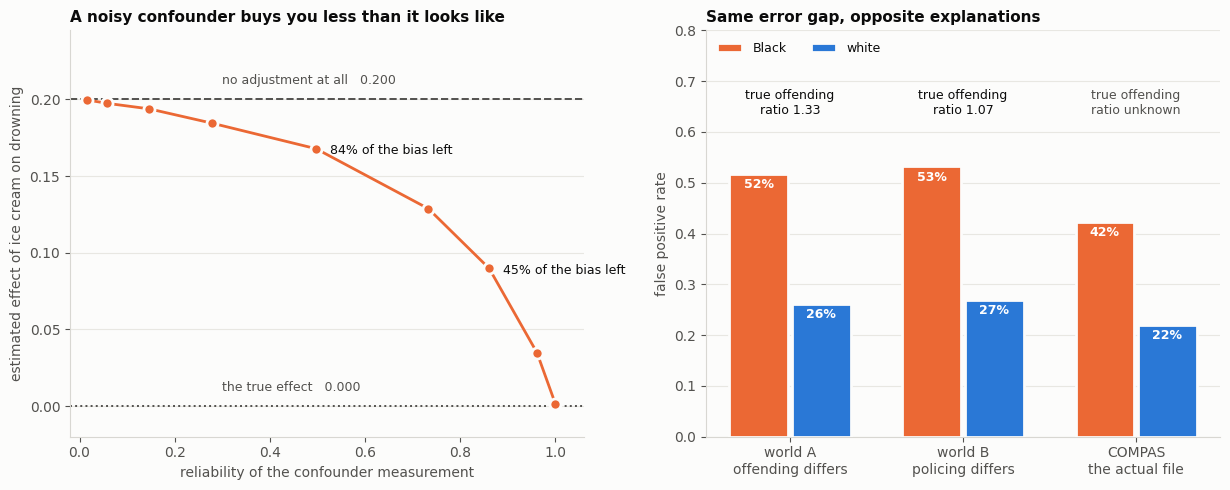

In [13]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, axis='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis=axis, color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.0))

# ---- left: how much bias a noisy confounder leaves behind
rel = [s[0] for s in sweep]
val = [s[1] for s in sweep]
ax1.axhline(b_none[1], color=MUTED, lw=1.4, ls='--', zorder=1)
ax1.axhline(0, color=MUTED, lw=1.4, ls=':', zorder=1)
ax1.plot(rel, val, color=ORANGE, lw=2, marker='o', ms=8,
         mec=SURFACE, mew=2, zorder=3)
ax1.text(0.30, b_none[1] + 0.008, f'no adjustment at all   {b_none[1]:.3f}',
         color=MUTED, fontsize=9, va='bottom')
ax1.text(0.30, 0.008, 'the true effect   0.000', color=MUTED, fontsize=9, va='bottom')
for r_, v_ in zip(rel, val):
    if r_ in (rel[2], rel[4]):
        ax1.annotate(f'{v_ / b_none[1]:.0%} of the bias left',
                     (r_, v_), textcoords='offset points', xytext=(10, -4),
                     fontsize=9, color=INK)
ax1.set_xlabel('reliability of the confounder measurement')
ax1.set_ylabel('estimated effect of ice cream on drowning')
ax1.set_title('A noisy confounder buys you less than it looks like', loc='left')
ax1.set_xlim(-0.02, 1.06)
ax1.set_ylim(-0.02, 0.245)
tidy(ax1)

# ---- right: two worlds, one observed file
labels = ['world A\noffending differs', 'world B\npolicing differs', 'COMPAS\nthe actual file']
fpr_b = [worlds['A']['fpr_b'], worlds['B']['fpr_b'], 0.423]
fpr_w = [worlds['A']['fpr_w'], worlds['B']['fpr_w'], 0.220]
off_r = [worlds['A']['off_b'] / worlds['A']['off_w'], worlds['B']['off_b'] / worlds['B']['off_w'], None]
x = np.arange(3)
w = 0.34
for i, (vals, colour, lab) in enumerate(((fpr_b, ORANGE, 'Black'), (fpr_w, BLUE, 'white'))):
    bars = ax2.bar(x + (i - 0.5) * (w + 0.02), vals, w, color=colour, label=lab,
                   zorder=3, edgecolor=SURFACE, linewidth=2)
    for b_, v_ in zip(bars, vals):
        ax2.text(b_.get_x() + b_.get_width() / 2, v_ - 0.028, f'{v_:.0%}',
                 ha='center', color='white', fontsize=9, fontweight='bold', zorder=4)
for xi, r_ in zip(x, off_r):
    txt = 'true offending\nratio unknown' if r_ is None else f'true offending\nratio {r_:.2f}'
    ax2.text(xi, 0.635, txt, ha='center', fontsize=9,
             color=INK if r_ is not None else MUTED)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylim(0, 0.80)
ax2.set_ylabel('false positive rate')
ax2.set_title('Same error gap, opposite explanations', loc='left')
ax2.legend(frameon=False, ncol=2, loc='upper left', fontsize=9)
tidy(ax2)

fig.tight_layout()
fig.savefig('../figures/09_causal.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

Left: the adjustment you can actually make with an imperfect measurement of a
confounder, against the one you would like to make. The curve is not linear in
reliability, and the middle of it is where most real analyses sit.

Right: two simulated worlds and the real file. The error gap is the same
shape in all three. The number written above each pair - the ratio of true
offending rates - is the thing that differs, and it is the one quantity that
appears in no column of any of them.

## Where this leaves the repository

Notebook 6 said the COMPAS argument had no right answer, and gave the reason:
Chouldechova's theorem, which says the two sides wanted incompatible things.
That is true and it is only the second-order problem.

The first-order problem is that both sides were computing statistics of a label
that measures arrests, and no analysis of that file recovers what it would have
said about offending. The fairness criteria were being argued over a quantity
neither party had.

None of this makes the measurements in notebooks 1 to 8 wrong. It fixes what they
are measurements *of*, which is the same correction notebook 2 makes about the
label and the same one Obermeyer et al. made about cost standing in for need. It
is the recurring failure in this field, and it is not a statistical error. It is
a reading error about what was recorded.